# 05 — Patient Satisfaction & Survey Non-Response

**Business question:** Who answers the post-visit satisfaction survey, and does the ~73% non-response
rate bias the score that gets reported to leadership?


## Methodology

`docs/measure_spec.md` requires mean satisfaction to never be reported without its response rate
alongside it, because responders are self-selected. This notebook tests whether response is associated
with two *observed* variables -- wait time and admission status -- using response rate by subgroup and
point-biserial correlation (`corr(x, responded_as_0_or_1)`). This can rule out bias along those two
axes; it cannot prove the missingness is random with respect to variables this warehouse does not
capture (true satisfaction itself, being the obvious candidate).


In [1]:
import sys
from pathlib import Path

# Make the shared erops package importable when the kernel's cwd is notebooks/.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import pandas as pd
import plotly.express as px
import plotly.io as pio

# Static PNG output so every chart renders identically in Jupyter, VS Code,
# nbviewer and GitHub's notebook preview -- no JS runtime required to view it.
pio.renderers.default = "png"
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

from erops import metrics

con = metrics.get_connection()
print(f"Connected to {metrics.WAREHOUSE}")


Connected to C:\Users\dhwan\OneDrive\Desktop\PROJECTS\er-throughput-analytics\data\er.duckdb


### Overall response rate


In [2]:
overview = metrics.satisfaction_overview(con)
print(f"Responders: {overview['responders']:,.0f} / {overview['total']:,.0f} "
      f"({overview['response_rate']:.1%})")
print(f"Mean score among responders: {overview['mean_score']:.2f} (SD {overview['sd_score']:.2f}), "
      f"0-10 scale")


Responders: 2,517 / 9,216 (27.3%)
Mean score among responders: 4.99 (SD 3.14), 0-10 scale


Only 27.3% of visits have a satisfaction score. Any headline "mean satisfaction = 4.99" figure is
computed over roughly a quarter of all visits -- the question this notebook exists to answer is whether
that quarter looks like the other three quarters.

> **Business decision this supports:** motivates every check below; a response rate this low makes
> representativeness the central question, not a footnote.


### Response rate by wait bucket


In [3]:
by_wait = metrics.satisfaction_by_wait_bucket(con)
by_wait


,wait_bucket,response_rate,mean_score,n
0,<=30 min,0.269138,5.039643,3749
1,>30 min,0.275837,4.960212,5467


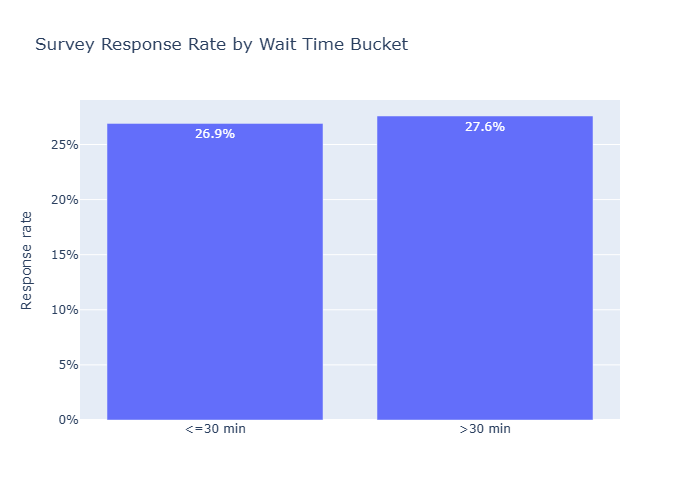

In [4]:
fig = px.bar(by_wait, x="wait_bucket", y="response_rate", text=by_wait["response_rate"].map(lambda v: f"{v:.1%}"),
             title="Survey Response Rate by Wait Time Bucket")
fig.update_layout(xaxis_title="", yaxis_title="Response rate", yaxis_tickformat=".0%")
fig.show()


### Response rate by admission status


In [5]:
by_admit = metrics.satisfaction_by_admitted(con)
by_admit


,admitted_flag,response_rate,mean_score,n
0,False,0.278454,4.910296,4604
1,True,0.267780,5.076923,4612


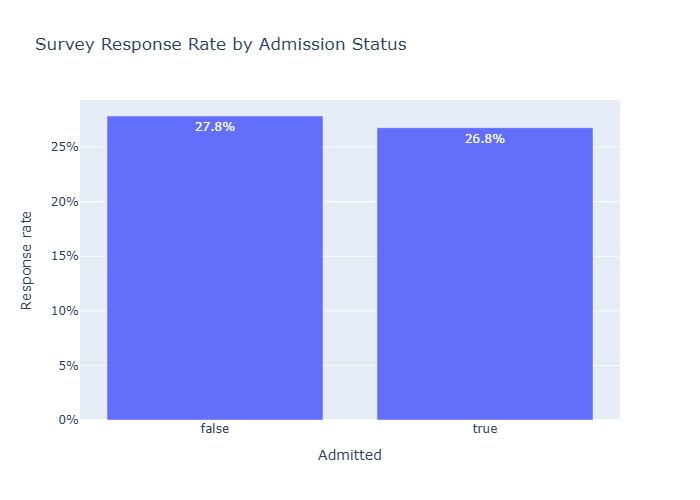

In [6]:
fig = px.bar(by_admit, x="admitted_flag", y="response_rate", text=by_admit["response_rate"].map(lambda v: f"{v:.1%}"),
             title="Survey Response Rate by Admission Status")
fig.update_layout(xaxis_title="Admitted", yaxis_title="Response rate", yaxis_tickformat=".0%")
fig.show()


### Correlation and mean wait by response group


In [7]:
bias = metrics.satisfaction_nonresponse_bias(con)
print(f"corr(wait_minutes, responded): {bias['corr_wait_responded']:.4f}")
print(f"corr(admitted, responded): {bias['corr_admitted_responded']:.4f}")
bias["by_response_group"]


corr(wait_minutes, responded): 0.0038
corr(admitted, responded): -0.0120


,responded,mean_wait,median_wait,n
0,False,35.225556,35.0,6699
1,True,35.351212,36.0,2517


Response rate is essentially flat across wait buckets and admission status (differences of a percentage
point or two), and both correlations are near zero (|r| < 0.02). Mean wait for responders (35.4 min) and
non-responders (35.2 min) is nearly identical. On the two axes this warehouse can observe, non-response
does not appear to be driven by wait time or by whether the patient was admitted.

> **Business decision this supports:** the reported mean satisfaction score is not obviously distorted
> by wait-time or admission-status selection bias -- these two candidate explanations for "unhappy long
> waiters skip the survey" or "admitted patients respond differently" are not supported here. This is
> reassuring but not conclusive (see Limitations).


## Executive Summary

Only 27.3% of visits carry a satisfaction score. Response propensity shows no meaningful association
with wait time (r = 0.004) or admission status (r = -0.012, both statistically negligible), and mean
wait is nearly identical between responders and non-responders (35.4 vs 35.2 minutes). The evidence
available in this warehouse does not support the specific hypothesis that longer waits or admission
suppress survey response.

## Business Recommendations

- Continue reporting the response rate (27.3%) alongside every satisfaction figure -- this analysis
  rules out two plausible bias mechanisms but does not certify the score as fully representative.
- Investigate raising the response rate itself (e.g. a shorter survey, a different delivery channel, or
  a small incentive) rather than assuming the current 4.99/10 mean is safe to act on as-is.
- If a targeted push to raise response rate is run, re-execute this notebook against the new data to
  check whether the newly-captured responses change the mean materially -- that comparison is itself
  the strongest test of non-response bias available.

## Limitations

- This analysis can only test association with *observed* variables (wait time, admission status). It
  cannot test whether non-response correlates with the patient's actual (unmeasured) satisfaction --
  the single most concerning form of non-response bias (MNAR: patients who leave unhappy and skip the
  survey) is invisible to this method by construction.
- No timestamp exists for when the survey was completed relative to discharge, so response timing
  effects (e.g. survey fatigue, delivery mechanism) cannot be examined.
- Response rate itself may vary by unobserved factors (department, shift, individual provider) not
  tested here.

## Next Steps

`06_segment_equity.ipynb` closes the analytical phase by asking whether wait time itself differs across
patient demographic groups.
